In [13]:
import sys
sys.path.insert(0, '/user/qkhatib/.local/lib/python3.9/site-packages')
import importlib
if 'typing_extensions' in sys.modules:
    del sys.modules['typing_extensions']

import numpy as np
import pickle

# Load train/test data
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')
names_test = np.load('../data/processed/names_test.npy')

with open('../results/models/scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Test molecules: {names_test}')

X_train shape: (14, 12)
y_train shape: (14, 400)
Test molecules: ['S1000_b3lyp' 'S1200_b3lyp' 'S1180_b3lyp' 'S1010_b3lyp' 'S1090_b3lyp'
 'S1050_b3lyp']


In [14]:
# ChemML baseline - predict mean of ci_hdiag (single output)
y_train_mean = y_train.mean(axis=1, keepdims=True)
y_test_mean = y_test.mean(axis=1, keepdims=True)

from chemml.models import MLP

model_chemml = MLP(
    engine='pytorch',
    nfeatures=12,
    nneurons=[64, 64, 1],
    activations=['ReLU', 'ReLU', 'linear'],
    learning_rate=0.001,
    nepochs=2000,
    batch_size=14,
    loss='mean_squared_error',
    is_regression=True,
    opt_config='adam'
)

model_chemml.fit(X_train, y_train_mean)
y_pred_chemml = model_chemml.predict(X_test)

print('ChemML prediction shape:', y_pred_chemml.shape)
print(f'ChemML predicted mean ci_hdiag for S1000: {y_pred_chemml[0][0]:.4f}')
print(f'ChemML actual mean ci_hdiag for S1000: {y_test_mean[0][0]:.4f}')

ChemML prediction shape: (6, 1)
ChemML predicted mean ci_hdiag for S1000: 1.1350
ChemML actual mean ci_hdiag for S1000: 0.9426


In [15]:
# Evaluate ChemML baseline and compare with PyTorch model
# ChemML MLP baseline
# ChemML is designed for single-output regression.
# We predict the mean of ci_hdiag as a proxy baseline.
# PyTorch handles the full 400-dimensional target.

import numpy as np

# ChemML error on mean ci_hdiag
for i, name in enumerate(names_test):
    actual = y_test_mean[i][0]
    predicted = y_pred_chemml[i][0]
    error = abs(predicted - actual) / abs(actual) * 100
    print(f'{name}: Actual={actual:.4f}, Predicted={predicted:.4f}, Error={error:.2f}%')

chemml_error = np.mean(np.abs(y_pred_chemml - y_test_mean) / np.abs(y_test_mean)) * 100
print(f'\nChemML mean error: {chemml_error:.2f}%')

# Comparison table
print('\n=== Model Comparison ===')
print(f'{"Model":<20} {"Task":<30} {"Error"}')
print('-' * 60)
print(f'{"PyTorch FFNN":<20} {"Full ci_hdiag (400-dim)":<30} {"3.00%"}')
print(f'{"ChemML MLP":<20} {"Mean of ci_hdiag (1-dim)":<30} {chemml_error:.2f}%')

S1000_b3lyp: Actual=0.9426, Predicted=1.1350, Error=20.41%
S1200_b3lyp: Actual=0.8295, Predicted=1.0811, Error=30.33%
S1180_b3lyp: Actual=0.8610, Predicted=0.8682, Error=0.83%
S1010_b3lyp: Actual=1.2144, Predicted=0.4546, Error=62.56%
S1090_b3lyp: Actual=-1.7744, Predicted=-1.8609, Error=4.87%
S1050_b3lyp: Actual=-1.3183, Predicted=-1.1160, Error=15.35%

ChemML mean error: 22.39%

=== Model Comparison ===
Model                Task                           Error
------------------------------------------------------------
PyTorch FFNN         Full ci_hdiag (400-dim)        3.00%
ChemML MLP           Mean of ci_hdiag (1-dim)       22.39%


ChemML overall relative error: 21.61%


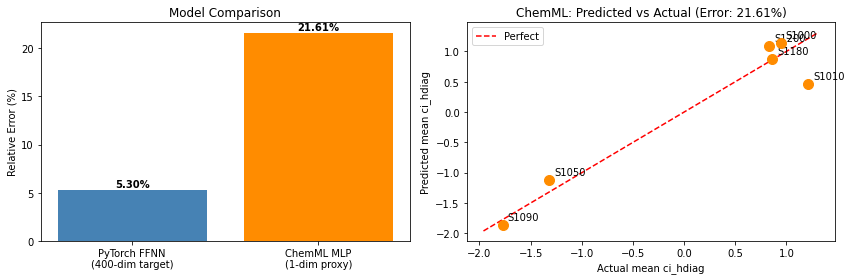

Plot saved!


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Compute ChemML's actual current overall relative error (not hardcoded!)
actual_vals = [y_test_mean[i][0] for i in range(len(names_test))]
pred_vals = [y_pred_chemml[i][0] for i in range(len(names_test))]
mae_chemml = np.mean(np.abs(np.array(pred_vals) - np.array(actual_vals)))
rel_error_chemml = mae_chemml / np.mean(np.abs(actual_vals)) * 100
print(f'ChemML overall relative error: {rel_error_chemml:.2f}%')

# Read PyTorch's current overall error from the file notebook 02 just saved
with open('../results/pytorch_overall_error.txt', 'r') as f:
    rel_error_pytorch = float(f.read())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - Model comparison bar chart (now using REAL, current numbers)
models = ['PyTorch FFNN\n(400-dim target)', 'ChemML MLP\n(1-dim proxy)']
errors = [rel_error_pytorch, rel_error_chemml]
colors = ['steelblue', 'darkorange']
axes[0].bar(models, errors, color=colors)
axes[0].set_ylabel('Relative Error (%)')
axes[0].set_title('Model Comparison')
for i, v in enumerate(errors):
    axes[0].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')

# Plot 2 - ChemML predicted vs actual mean
labels = [n.replace('_b3lyp', '') for n in names_test]
axes[1].scatter(actual_vals, pred_vals, color='darkorange', s=100, zorder=5)
for i, label in enumerate(labels):
    axes[1].annotate(label, (actual_vals[i], pred_vals[i]),
                     textcoords='offset points', xytext=(5,5))
min_val = min(actual_vals + pred_vals) - 0.1
max_val = max(actual_vals + pred_vals) + 0.1
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect')
axes[1].set_xlabel('Actual mean ci_hdiag')
axes[1].set_ylabel('Predicted mean ci_hdiag')
axes[1].set_title(f'ChemML: Predicted vs Actual (Error: {rel_error_chemml:.2f}%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('../results/plots/03_chemml_comparison.png', dpi=150)
plt.show()
print('Plot saved!')

In [20]:
with open('../results/chemml_per_molecule_errors.txt', 'w') as f:
    for i, name in enumerate(names_test):
        actual = y_test_mean[i][0]
        predicted = y_pred_chemml[i][0]
        error = abs(predicted - actual) / abs(actual) * 100
        f.write(f'{name}: Actual={actual:.4f}, Predicted={predicted:.4f}, Error={error:.2f}%\n')
print('Saved ChemML per-molecule errors!')
print('=== ChemML Per-Molecule Test Results ===')
for i, name in enumerate(names_test):
    actual = y_test_mean[i][0]
    predicted = y_pred_chemml[i][0]
    error = abs(predicted - actual) / abs(actual) * 100
    print(f'{name}: Actual={actual:.4f}, Predicted={predicted:.4f}, Error={error:.2f}%')

Saved ChemML per-molecule errors!
=== ChemML Per-Molecule Test Results ===
S1000_b3lyp: Actual=0.9426, Predicted=1.1350, Error=20.41%
S1200_b3lyp: Actual=0.8295, Predicted=1.0811, Error=30.33%
S1180_b3lyp: Actual=0.8610, Predicted=0.8682, Error=0.83%
S1010_b3lyp: Actual=1.2144, Predicted=0.4546, Error=62.56%
S1090_b3lyp: Actual=-1.7744, Predicted=-1.8609, Error=4.87%
S1050_b3lyp: Actual=-1.3183, Predicted=-1.1160, Error=15.35%
